# 06 — Grade Inference on New Cards

Loads the trained MLP from `grade_mlp_best.pt` and predicts PSA grade buckets
for any card images you drop into the `cards/` folder.

**Prerequisites:** Run `05_feature_model.ipynb` through Step 10 to produce `grade_mlp_best.pt`.

**Usage:**
1. Drop card images (`.jpg`, `.jpeg`, `.png`) into `notebooks/cards/`
2. Run all cells top-to-bottom
3. Each card gets a predicted grade bucket + confidence breakdown

| Output | Meaning |
|--------|---------|
| **Mint (9-10)** | Gem-quality, no visible defects |
| **Near Mint (7-8)** | Minor wear, strong investment card |
| **Excellent (5-6)** | Light play wear |
| **Very Good (3-4)** | Visible wear |
| **Poor (1-2)** | Heavy damage |

In [1]:
# ── Install + imports ─────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch', 'torchvision', 'timm',
                       'opencv-python', 'numpy', 'matplotlib', 'Pillow'])

import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import pickle, warnings, re as _re
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130, 'axes.facecolor': '#0d1117',
    'figure.facecolor': '#0d1117', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white',
})

DEVICE = torch.device('cuda'  if torch.cuda.is_available() else
                      'mps'   if torch.backends.mps.is_available() else 'cpu')
CARD_H, CARD_W = 420, 300

BUCKET_NAMES   = ['Poor\n(1-2)', 'VG\n(3-4)', 'Excellent\n(5-6)', 'NM\n(7-8)', 'Mint\n(9-10)']
BUCKET_COLORS  = ['#7f1d1d', '#b91c1c', '#f97316', '#4ade80', '#22c55e']
NUM_CLASSES    = 5

CARDS_DIR  = Path('cards')
MODEL_PATH = Path('grade_mlp_best.pt')
CACHE_DIR  = Path('datasets/feature_cache')

print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_PATH}  (exists: {MODEL_PATH.exists()})')
print(f'Cards  : {CARDS_DIR}  (exists: {CARDS_DIR.exists()})')

Device : mps
Model  : grade_mlp_best.pt  (exists: True)
Cards  : cards  (exists: True)


## Step 1 — Load Trained Model

In [2]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f'{MODEL_PATH} not found.\n'
        'Run 05_feature_model.ipynb through Step 10 first to train and save the model.'
    )

# ── Rebuild the same MLP architecture from checkpoint ────────────
class GradeMLP(nn.Module):
    def __init__(self, input_dim, num_classes=NUM_CLASSES,
                 hidden_dims=(256, 128, 64), dropout=0.4):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


ckpt = torch.load(MODEL_PATH, map_location='cpu', weights_only=False)

MODEL_NAME   = ckpt['model_name']
MODEL_MODE   = ckpt['mode']           # 'cv', 'cnn', or 'combined'
CV_MODE      = ckpt.get('cv_mode', 'base')
BACKBONE     = ckpt.get('backbone', 'resnet18')
FEAT_NAMES   = ckpt.get('feature_names', [])
INPUT_DIM    = ckpt['input_dim']

model = GradeMLP(
    input_dim   = INPUT_DIM,
    num_classes = ckpt['num_classes'],
    hidden_dims = ckpt['hidden_dims'],
    dropout     = ckpt['dropout'],
)
model.load_state_dict(ckpt['model_state'])
model = model.to(DEVICE).eval()

print(f'✅ Loaded: {MODEL_NAME}')
print(f'   Mode       : {MODEL_MODE}')
print(f'   Input dim  : {INPUT_DIM}')
print(f'   CV mode    : {CV_MODE}  ({len(FEAT_NAMES)} feature names)')
print(f'   Backbone   : {BACKBONE}')
print(f'   Val acc    : {ckpt["val_acc"]:.3f}')

✅ Loaded: Combined-MLP
   Mode       : combined
   Input dim  : 839
   CV mode    : ext  (71 feature names)
   Backbone   : convnext_tiny.fb_in22k_ft_in1k
   Val acc    : 0.544


## Step 2 — Load CNN Backbone (if needed)

In [3]:
cnn_model     = None
cnn_transform = None
CNN_DIM       = 0

if MODEL_MODE in ('cnn', 'combined'):
    import timm
    print(f'Loading backbone: {BACKBONE} …')
    cnn_model = timm.create_model(BACKBONE, pretrained=True, num_classes=0)
    cnn_model = cnn_model.to(DEVICE).eval()
    for p in cnn_model.parameters():
        p.requires_grad = False
    CNN_DIM      = cnn_model.num_features
    data_cfg     = timm.data.resolve_model_data_config(cnn_model)
    cnn_transform = timm.data.create_transform(**data_cfg, is_training=False)
    print(f'✅ {BACKBONE}  →  {CNN_DIM}-dim embeddings')
else:
    print(f'Model mode is "{MODEL_MODE}" — no CNN backbone needed')

Loading backbone: convnext_tiny.fb_in22k_ft_in1k …
✅ convnext_tiny.fb_in22k_ft_in1k  →  768-dim embeddings


## Step 3 — Feature Extractors

Identical to `05_feature_model.ipynb` — CV (20-dim base + 51-dim extended = 71 total) and CNN embeddings.

In [4]:
def extract_cv_features(img_path, card_h=CARD_H, card_w=CARD_W):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img  = cv2.resize(img, (card_w, card_h))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv  = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, w = gray.shape
    corner_size = max(20, h // 14)
    corners = [gray[:corner_size, :corner_size], gray[:corner_size, w-corner_size:],
               gray[h-corner_size:, :corner_size], gray[h-corner_size:, w-corner_size:]]
    corner_scores = [float(np.clip(cv2.Laplacian(p, cv2.CV_32F).var() / 500.0 * 100, 0, 100))
                     for p in corners]
    corner_mean = float(np.mean(corner_scores))
    border = max(8, h // 50)
    strips = [gray[:border,:], gray[h-border:,:], gray[:,:border], gray[:,w-border:]]
    edge_scores = []
    for s in strips:
        sob = cv2.Sobel(s.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
        edge_scores.append(float(np.clip((1 - np.std(sob)/(np.mean(np.abs(sob))+1e-6)/10)*100, 0, 100)))
    edge_mean = float(np.mean(edge_scores))
    inner = gray[border*2:h-border*2, border*2:w-border*2]
    blur  = cv2.GaussianBlur(inner, (3,3), 0)
    diff  = cv2.absdiff(inner, blur)
    scratch_density = float(np.sum(diff > 15) / diff.size)
    surface_score   = float(np.clip((1-scratch_density*20)*100, 0, 100))
    color_uniformity = float(np.std(hsv[border*2:h-border*2, border*2:w-border*2, 2].astype(np.float32)))
    _, thr = cv2.threshold(inner, 30, 255, cv2.THRESH_BINARY_INV)
    cnts, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    stain_count = float(sum(1 for c in cnts if cv2.contourArea(c) > 100))
    stain_score = float(np.clip(100 - stain_count*5, 0, 100))
    col_proj = gray.mean(axis=0).astype(np.float32)
    row_proj = gray.mean(axis=1).astype(np.float32)
    thresh_val = float(col_proj.mean()) * 0.85
    def _bw(proj, rev=False):
        seq = proj[::-1] if rev else proj
        for i, v in enumerate(seq):
            if v > thresh_val: return max(i, 1)
        return len(proj) // 4
    l,r,t,b2 = _bw(col_proj), _bw(col_proj,True), _bw(row_proj), _bw(row_proj,True)
    lr_ratio = float(min(l,r)/max(l,r)) if max(l,r)>0 else 1.0
    tb_ratio = float(min(t,b2)/max(t,b2)) if max(t,b2)>0 else 1.0
    centering_score = float((lr_ratio*0.5 + tb_ratio*0.5)*100)
    brightness = float(gray.mean())
    contrast   = float(gray.std())
    blur_score = float(np.clip(cv2.Laplacian(gray, cv2.CV_32F).var() / 1000.0 * 100, 0, 100))
    return np.array([
        corner_mean, *corner_scores,
        edge_mean, *edge_scores,
        surface_score, scratch_density*100, color_uniformity, stain_score,
        centering_score, lr_ratio*100, tb_ratio*100,
        brightness, contrast, blur_score,
    ], dtype=np.float32)


def _glcm(patch, levels=32):
    q = np.clip((patch.astype(np.float32)/8).astype(np.int32), 0, levels-1)
    g = np.zeros((levels,levels), dtype=np.float32)
    g[q[:-1,:].ravel(), q[1:,:].ravel()] += 1
    g += g.T; g /= (g.sum()+1e-10)
    i,j = np.mgrid[0:levels,0:levels]
    hom = float(np.sum(g/(1+(i-j)**2)))
    ene = float(np.sqrt(np.sum(g**2)))
    con = float(np.sum(g*(i-j)**2))
    mi,mj = float(np.sum(i*g)), float(np.sum(j*g))
    si = float(np.sqrt(np.sum(g*(i-mi)**2)+1e-10))
    sj = float(np.sqrt(np.sum(g*(j-mj)**2)+1e-10))
    cor = float(np.sum(g*(i-mi)*(j-mj))/(si*sj+1e-10))
    return hom, ene, con, cor


def extract_extended_cv_features(img_path, card_h=CARD_H, card_w=CARD_W):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img   = cv2.resize(img, (card_w, card_h))
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, w  = gray.shape
    gray_f = gray.astype(np.float32)
    border = max(8, h//50); corner_size = max(20, h//14)
    cy,cx,cs = h//2, w//2, max(20, h//10)
    center_bright = float(gray_f[cy-cs:cy+cs, cx-cs:cx+cs].mean()) + 1e-6
    patches = [gray[:corner_size,:corner_size], gray[:corner_size,w-corner_size:],
               gray[h-corner_size:,:corner_size], gray[h-corner_size:,w-corner_size:]]
    cw = [float(np.clip(p.mean()/center_bright,0,3)) for p in patches]
    cr = []
    for p in patches:
        _,thr=cv2.threshold(p,200,255,cv2.THRESH_BINARY)
        cnts,_=cv2.findContours(thr,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        cr.append(float(cv2.contourArea(max(cnts,key=cv2.contourArea))/corner_size**2) if cnts else 0.0)
    ce = []
    for p in patches:
        hist=cv2.calcHist([p],[0],None,[32],[0,256]).ravel(); hist/=(hist.sum()+1e-6)
        ce.append(-float(np.sum(hist*np.log2(hist+1e-10))))
    strips=[gray[:border*2,:],gray[h-border*2:,:],gray[:,:border*2],gray[:,w-border*2:]]
    axes=[0,0,1,1]
    chip=[float(np.clip(100-np.sum(np.abs(np.diff(s.astype(np.float32).mean(axis=ax)))>20)*2,0,100))
          for s,ax in zip(strips,axes)]
    ewh=[float(np.clip(s.astype(np.float32).mean()/center_bright,0,3)) for s in strips]
    inner=gray[border*3:h-border*3, border*3:w-border*3]
    ec=cv2.Canny(inner,30,80)
    lines=cv2.HoughLinesP(ec,1,np.pi/180,20,minLineLength=20,maxLineGap=5)
    sc=float(len(lines)) if lines is not None else 0.0
    sh=float(np.clip(100-sc*2,0,100))
    fft=np.abs(np.fft.fftshift(np.fft.fft2(inner.astype(np.float32))))
    fy,fx=fft.shape[0]//2,fft.shape[1]//2; fft[fy-2:fy+2,fx-2:fx+2]=0
    hb=fft[fy-20:fy+20,:].max(axis=0); vb=fft[:,fx-20:fx+20].max(axis=1)
    hp=float(hb.max()/(hb.mean()+1e-6)); vp=float(vb.max()/(vb.mean()+1e-6))
    pl=float(np.clip(100-(max(hp,vp)-1)*2,0,100))
    gh,ge,gc,gcor=_glcm(inner)
    gr=[float(cv2.filter2D(inner.astype(np.float32),cv2.CV_32F,
               cv2.getGaborKernel((15,15),3,t,8,0.5,0)).mean())
        for t in (0,np.pi/4,np.pi/2,3*np.pi/4)]
    b_ch,g_ch,r_ch=cv2.split(img)
    rm,gm,bm=float(r_ch.astype(np.float32).mean()),float(g_ch.astype(np.float32).mean()),float(b_ch.astype(np.float32).mean())
    rs,gs,bs=float(r_ch.astype(np.float32).std()),float(g_ch.astype(np.float32).std()),float(b_ch.astype(np.float32).std())
    sm,ss,hs=float(hsv[:,:,1].mean()),float(hsv[:,:,1].std()),float(hsv[:,:,0].std())
    cp=gray_f.mean(axis=0); rp=gray_f.mean(axis=1); tv=cp.mean()*0.85
    def _bw2(p,rev=False):
        s=p[::-1] if rev else p
        for i,v in enumerate(s):
            if v>tv: return max(i,1)
        return len(p)//4
    bwl=_bw2(cp)/w; bwr=_bw2(cp,True)/w; bwt=_bw2(rp)/h; bwb=_bw2(rp,True)/h
    ad=float(abs(w/h-0.714))
    hfr=float(np.abs(gray_f-cv2.GaussianBlur(gray_f,(15,15),0)).mean()/(gray_f.mean()+1e-6))
    return np.array([
        float(np.mean(cw)),*cw, float(np.mean(cr)),*cr, float(np.mean(ce)),*ce,
        float(np.mean(chip)),*chip, float(np.mean(ewh)),*ewh,
        sh,sc, pl,hp,vp, gh,ge,gc,gcor, float(max(gr)),float(np.var(gr)),
        rm,gm,bm, rs,gs,bs, sm,ss,hs,
        bwl,bwr,bwt,bwb, ad,hfr,
    ], dtype=np.float32)


def extract_all_cv(img_path):
    base = extract_cv_features(img_path)
    ext  = extract_extended_cv_features(img_path)
    if base is None or ext is None: return None
    return np.concatenate([base, ext])


def extract_cnn(img_path):
    if cnn_model is None: return None
    img = cv2.imread(str(img_path))
    if img is None: return None
    from PIL import Image as _PIL
    pil = _PIL.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    t   = cnn_transform(pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        return cnn_model(t).squeeze(0).cpu().numpy().astype(np.float32)


print('✅ Feature extractors ready')
_cv_fn = extract_all_cv if CV_MODE == 'ext' else extract_cv_features
print(f'   CV: {"extended 71-dim" if CV_MODE=="ext" else "base 20-dim"}')
print(f'   CNN: {"enabled (" + str(CNN_DIM) + "-dim)" if cnn_model else "not needed"}')

✅ Feature extractors ready
   CV: extended 71-dim
   CNN: enabled (768-dim)


## Step 4 — Load Normalizer Stats

The model was trained on z-scored features. We derive the same mean/std
from the feature cache produced by `05_feature_model.ipynb`.

In [5]:
cv_mean = cv_std = cnn_mean = cnn_std = None

# ── Try to find a matching feature cache ──────────────────────────
backbone_slug = BACKBONE.replace('/', '_').replace('.', '_')
cache_file    = None

if CACHE_DIR.exists():
    # Prefer exact match on cv_mode + backbone, fall back to any pkl
    pattern  = f'features_*_{CV_MODE}_{backbone_slug}.pkl'
    matches  = list(CACHE_DIR.glob(pattern))
    fallback = list(CACHE_DIR.glob('features_*.pkl'))
    cache_file = (matches or fallback or [None])[0]

if cache_file and cache_file.exists():
    print(f'Loading feature cache: {cache_file.name} …')
    with open(cache_file, 'rb') as f:
        _cache = pickle.load(f)

    cv_mean  = _cache['cv_features'].mean(0,  keepdims=True).astype(np.float32)
    cv_std   = (_cache['cv_features'].std(0,  keepdims=True) + 1e-6).astype(np.float32)
    cnn_mean = _cache['cnn_features'].mean(0, keepdims=True).astype(np.float32)
    cnn_std  = (_cache['cnn_features'].std(0, keepdims=True) + 1e-6).astype(np.float32)

    print(f'✅ Normalizer from {len(_cache["paths"]):,}-sample cache')
    print(f'   CV  : mean={cv_mean.mean():.3f}  std={cv_std.mean():.3f}')
    print(f'   CNN : mean={cnn_mean.mean():.3f}  std={cnn_std.mean():.3f}')
    del _cache
else:
    print('⚠  No feature cache found — will skip normalization.')
    print('   Predictions may be less accurate.')
    print(f'   Expected cache in: {CACHE_DIR}')
    print(f'   Run 05_feature_model.ipynb through Step 3 to generate it.')


def _normalize(arr, mean, std):
    """Apply cached z-score normalization, or return raw if stats unavailable."""
    if mean is None or std is None:
        return arr
    return (arr - mean) / std

Loading feature cache: features_unified_ext_convnext_tiny_fb_in22k_ft_in1k.pkl …
✅ Normalizer from 11,500-sample cache
   CV  : mean=1686.117  std=630.345
   CNN : mean=-0.016  std=0.801


## Step 5 — Find Card Images

Scans `cards/` and the notebook root for any `.jpg`/`.jpeg`/`.png` files.
Front images are preferred for prediction when both front and back exist.

In [6]:
IMG_SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp'}

def _find_card_images():
    """
    Collect card images from:
      1. cards/  directory (all images)
      2. notebook root imageN_front/back.jpeg files
    Groups front+back pairs by stem prefix; prefers front for prediction.
    Returns list of dicts: {label, predict_path, front_path, back_path}
    """
    import re
    from collections import defaultdict

    candidates = defaultdict(dict)  # key → {front: path, back: path}

    # Root-level imageN_front/back files
    for p in Path('.').glob('image*.*'):
        if p.suffix.lower() not in IMG_SUFFIXES: continue
        m = re.match(r'(image\d+)_(front|back)', p.stem, re.IGNORECASE)
        if m:
            key, side = m.group(1), m.group(2).lower()
            candidates[key][side] = p

    # cards/ directory
    if CARDS_DIR.exists():
        for p in sorted(CARDS_DIR.iterdir()):
            if p.suffix.lower() not in IMG_SUFFIXES: continue
            m = re.match(r'(image\d+)_(front|back)', p.stem, re.IGNORECASE)
            if m:
                key, side = m.group(1), m.group(2).lower()
                # cards/ files supplement root (don't overwrite front if root has it)
                if side not in candidates[key]:
                    candidates[key][side] = p
            else:
                # Standalone file in cards/ with no front/back naming
                candidates[p.stem]['front'] = p

    cards = []
    for key in sorted(candidates.keys()):
        pair = candidates[key]
        predict_path = pair.get('front') or pair.get('back')
        cards.append({
            'label':        key,
            'predict_path': predict_path,
            'front_path':   pair.get('front'),
            'back_path':    pair.get('back'),
        })
    return cards


cards = _find_card_images()

if not cards:
    print('⚠  No card images found.')
    print(f'   Drop .jpg / .jpeg / .png files into: {CARDS_DIR.resolve()}')
    print('   Or name them imageN_front.jpg / imageN_back.jpg in the notebook root.')
else:
    print(f'Found {len(cards)} card(s):')
    for c in cards:
        front = c['front_path'].name if c['front_path'] else '—'
        back  = c['back_path'].name  if c['back_path']  else '—'
        pred  = '(front)' if c['front_path'] == c['predict_path'] else '(back)'
        print(f'  {c["label"]}  front={front}  back={back}  → predict from {pred}')

Found 3 card(s):
  image0  front=image0_front.jpeg  back=image0_back.jpeg  → predict from (front)
  image1  front=image1_front.jpeg  back=image1_back.jpeg  → predict from (front)
  image2  front=image2_front.jpeg  back=image2_back.jpeg  → predict from (front)


## Step 6 — Run Predictions

In [7]:
import torch.nn.functional as F

def predict_card(img_path):
    """
    Extract features for one card image, normalize, run the MLP.
    Returns (bucket_idx, probs_array, cv_features_raw).
    """
    # ── Feature extraction ────────────────────────────────────────
    cv_raw = _cv_fn(img_path)
    if cv_raw is None:
        raise ValueError(f'Could not read image: {img_path}')

    if MODEL_MODE == 'cv':
        feat = _normalize(cv_raw[None], cv_mean, cv_std).ravel()

    elif MODEL_MODE == 'cnn':
        cnn_raw = extract_cnn(img_path)
        if cnn_raw is None:
            raise ValueError(f'CNN extraction failed: {img_path}')
        feat = _normalize(cnn_raw[None], cnn_mean, cnn_std).ravel()

    else:  # combined
        cnn_raw = extract_cnn(img_path)
        if cnn_raw is None:
            raise ValueError(f'CNN extraction failed: {img_path}')
        cv_n   = _normalize(cv_raw[None],  cv_mean,  cv_std).ravel()
        cnn_n  = _normalize(cnn_raw[None], cnn_mean, cnn_std).ravel()
        feat   = np.concatenate([cv_n, cnn_n])

    # ── Inference ─────────────────────────────────────────────────
    x     = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(x)
    probs  = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    bucket = int(probs.argmax())

    return bucket, probs, cv_raw


# ── Run on all found cards ────────────────────────────────────────
results = []
if cards:
    print('Predicting …')
    for card in cards:
        try:
            bucket, probs, cv_feats = predict_card(card['predict_path'])
            results.append({
                **card,
                'bucket':   bucket,
                'probs':    probs,
                'cv_feats': cv_feats,
                'error':    None,
            })
            grade_str = BUCKET_NAMES[bucket].replace('\n', ' ')
            conf      = probs[bucket] * 100
            print(f'  {card["label"]:10}  →  {grade_str}  ({conf:.1f}% confidence)')
        except Exception as e:
            results.append({**card, 'bucket': None, 'probs': None,
                            'cv_feats': None, 'error': str(e)})
            print(f'  {card["label"]:10}  →  ERROR: {e}')
else:
    print('No cards to predict — add images to the cards/ folder and re-run.')

Predicting …
  image0      →  NM (7-8)  (99.4% confidence)
  image1      →  NM (7-8)  (89.2% confidence)
  image2      →  NM (7-8)  (95.6% confidence)


Premature end of JPEG file
Premature end of JPEG file
Premature end of JPEG file


## Step 7 — Visualize Results

Premature end of JPEG file


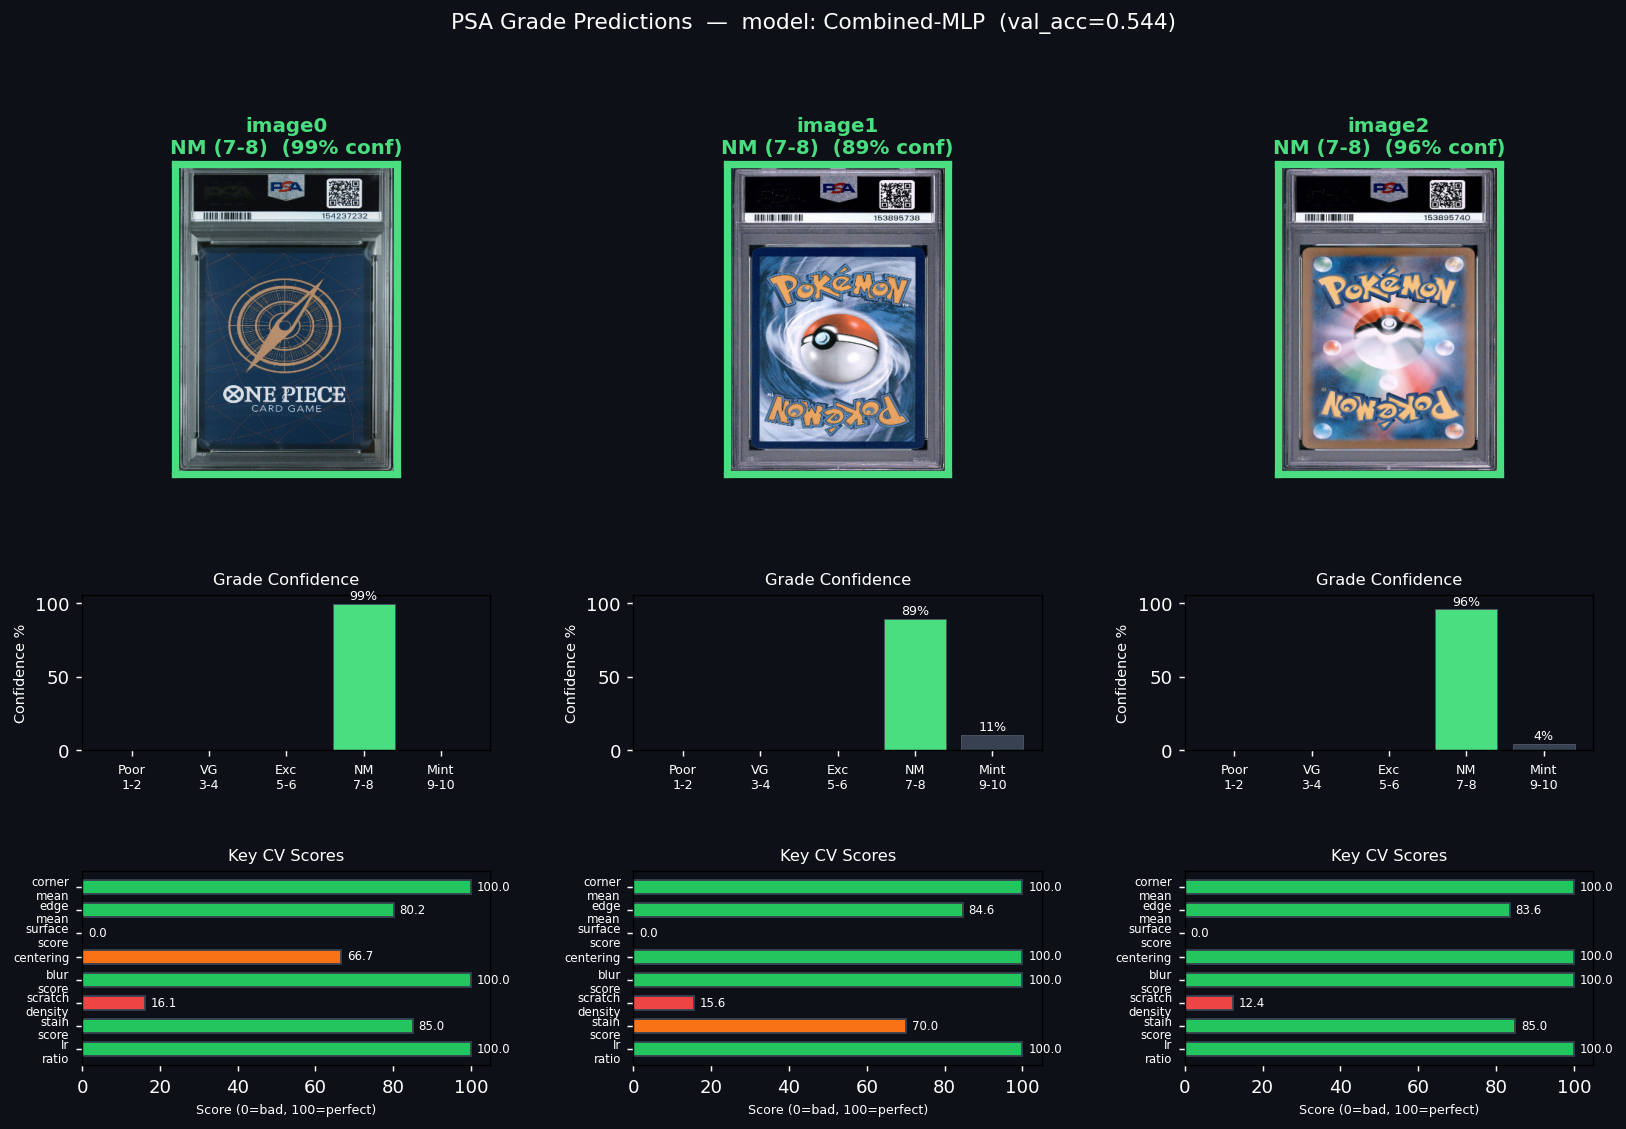

In [8]:
ok_results = [r for r in results if r['error'] is None]
if not ok_results:
    print('No successful predictions to show.')
else:
    n = len(ok_results)
    # Each card: image | confidence bars | CV radar
    fig = plt.figure(figsize=(5 * n, 9))
    outer = gridspec.GridSpec(1, n, figure=fig, wspace=0.35)

    for col, r in enumerate(ok_results):
        inner = gridspec.GridSpecFromSubplotSpec(
            3, 1, subplot_spec=outer[col],
            height_ratios=[4, 2, 2.5], hspace=0.55
        )
        bucket = r['bucket']
        probs  = r['probs']
        conf   = probs[bucket] * 100
        grade_str = BUCKET_NAMES[bucket].replace('\n', ' ')
        border_color = BUCKET_COLORS[bucket]

        # ── Panel 1: card image ───────────────────────────────────
        ax_img = fig.add_subplot(inner[0])
        display_path = r['front_path'] or r['back_path'] or r['predict_path']
        img_bgr = cv2.imread(str(display_path))
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (300, 420)), cv2.COLOR_BGR2RGB)
            ax_img.imshow(img_rgb)
            for spine in ax_img.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(4)
        ax_img.set_xticks([]); ax_img.set_yticks([])
        ax_img.set_title(
            f'{r["label"]}\n{grade_str}  ({conf:.0f}% conf)',
            color=border_color, fontsize=11, fontweight='bold', pad=6
        )

        # ── Panel 2: confidence bar chart ─────────────────────────
        ax_bar = fig.add_subplot(inner[1])
        short_names = ['Poor\n1-2', 'VG\n3-4', 'Exc\n5-6', 'NM\n7-8', 'Mint\n9-10']
        bars = ax_bar.bar(
            range(NUM_CLASSES), probs * 100,
            color=[BUCKET_COLORS[i] if i == bucket else '#374151'
                   for i in range(NUM_CLASSES)],
            edgecolor='#4b5563', linewidth=0.5
        )
        ax_bar.set_xticks(range(NUM_CLASSES))
        ax_bar.set_xticklabels(short_names, fontsize=7)
        ax_bar.set_ylabel('Confidence %', fontsize=8)
        ax_bar.set_ylim(0, 105)
        ax_bar.set_title('Grade Confidence', color='white', fontsize=9)
        for bar, p in zip(bars, probs):
            if p > 0.04:
                ax_bar.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 1,
                            f'{p*100:.0f}%',
                            ha='center', va='bottom',
                            fontsize=7, color='white')

        # ── Panel 3: top CV features (mini bar) ───────────────────
        ax_cv = fig.add_subplot(inner[2])
        cv_feats = r['cv_feats']
        if cv_feats is not None and FEAT_NAMES:
            # Normalise CV features to [0,1] using the cache stats
            n_names = min(len(FEAT_NAMES), len(cv_feats))
            show_n  = min(8, n_names)  # show 8 most interpretable features
            # Pick: corners, edges, surface, centering, blur
            priority = ['corner_mean','edge_mean','surface_score','centering',
                        'blur_score','scratch_density','stain_score','lr_ratio']
            idx_show = []
            for name in priority:
                matches = [i for i,n in enumerate(FEAT_NAMES[:n_names]) if n == name]
                if matches: idx_show.append(matches[0])
            # fill up to show_n
            for i in range(n_names):
                if len(idx_show) >= show_n: break
                if i not in idx_show: idx_show.append(i)

            vals  = cv_feats[idx_show]
            names = [FEAT_NAMES[i].replace('_', '\n') for i in idx_show]
            # Clip scratch_density, stain related to 0-100 scale
            vals_disp = np.clip(vals, 0, 100)
            colors_cv = ['#22c55e' if v > 70 else '#f97316' if v > 40 else '#ef4444'
                         for v in vals_disp]
            ax_cv.barh(range(len(idx_show)), vals_disp, color=colors_cv,
                       edgecolor='#374151', height=0.6)
            ax_cv.set_yticks(range(len(idx_show)))
            ax_cv.set_yticklabels(names, fontsize=6.5)
            ax_cv.set_xlim(0, 105)
            ax_cv.set_xlabel('Score (0=bad, 100=perfect)', fontsize=7)
            ax_cv.set_title('Key CV Scores', color='white', fontsize=9)
            ax_cv.invert_yaxis()
            for i, (v, vd) in enumerate(zip(vals, vals_disp)):
                ax_cv.text(vd + 1.5, i, f'{v:.1f}', va='center', fontsize=6.5, color='white')
        else:
            ax_cv.text(0.5, 0.5, 'CV features\nnot available',
                       ha='center', va='center', color='#6b7280', transform=ax_cv.transAxes)
            ax_cv.set_xticks([]); ax_cv.set_yticks([])

    plt.suptitle(
        f'PSA Grade Predictions  —  model: {MODEL_NAME}  (val_acc={ckpt["val_acc"]:.3f})',
        color='white', fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

## Step 8 — Results Table

In [9]:
if results:
    print(f'{'Card':<12} {'Predicted Grade':<22} {'Confidence':>11}  {'All bucket probs'}')
    print('─' * 80)
    for r in results:
        if r['error']:
            print(f'{r["label"]:<12}  ERROR: {r["error"]}')
            continue
        b     = r['bucket']
        grade = BUCKET_NAMES[b].replace('\n', ' ')
        conf  = r['probs'][b] * 100
        probs_str = '  '.join(f'B{i}:{p*100:4.1f}%' for i,p in enumerate(r['probs']))
        print(f'{r["label"]:<12}  {grade:<22}  {conf:>8.1f}%   {probs_str}')

    print()
    print('Bucket key:  B0=Poor(1-2)  B1=VG(3-4)  B2=Excellent(5-6)  B3=NM(7-8)  B4=Mint(9-10)')
    print(f'Model: {MODEL_NAME}  |  mode: {MODEL_MODE}  |  val_acc: {ckpt["val_acc"]:.3f}')

Card         Predicted Grade         Confidence  All bucket probs
────────────────────────────────────────────────────────────────────────────────
image0        NM (7-8)                    99.4%   B0: 0.0%  B1: 0.0%  B2: 0.2%  B3:99.4%  B4: 0.4%
image1        NM (7-8)                    89.2%   B0: 0.0%  B1: 0.0%  B2: 0.1%  B3:89.2%  B4:10.7%
image2        NM (7-8)                    95.6%   B0: 0.0%  B1: 0.0%  B2: 0.0%  B3:95.6%  B4: 4.3%

Bucket key:  B0=Poor(1-2)  B1=VG(3-4)  B2=Excellent(5-6)  B3=NM(7-8)  B4=Mint(9-10)
Model: Combined-MLP  |  mode: combined  |  val_acc: 0.544
